In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use("ggplot")

# Load dataset
df = pd.read_csv("../data/cleaned_books.csv")

# Display first five rows
df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1000, 4)

Columns:
Index(['Title', 'Price', 'Rating', 'Availability'], dtype='str')

Data Types:
Title               str
Price           float64
Rating            int64
Availability        str
dtype: object


In [4]:
df.describe()

,Price,Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


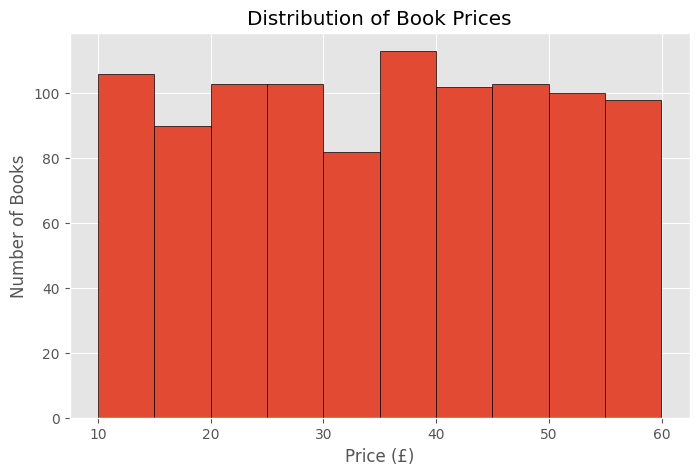

In [5]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=10, edgecolor="black")

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

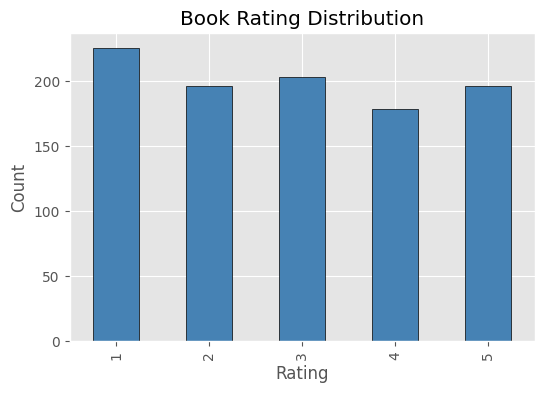

In [6]:
plt.figure(figsize=(6,4))

df["Rating"].value_counts().sort_index().plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

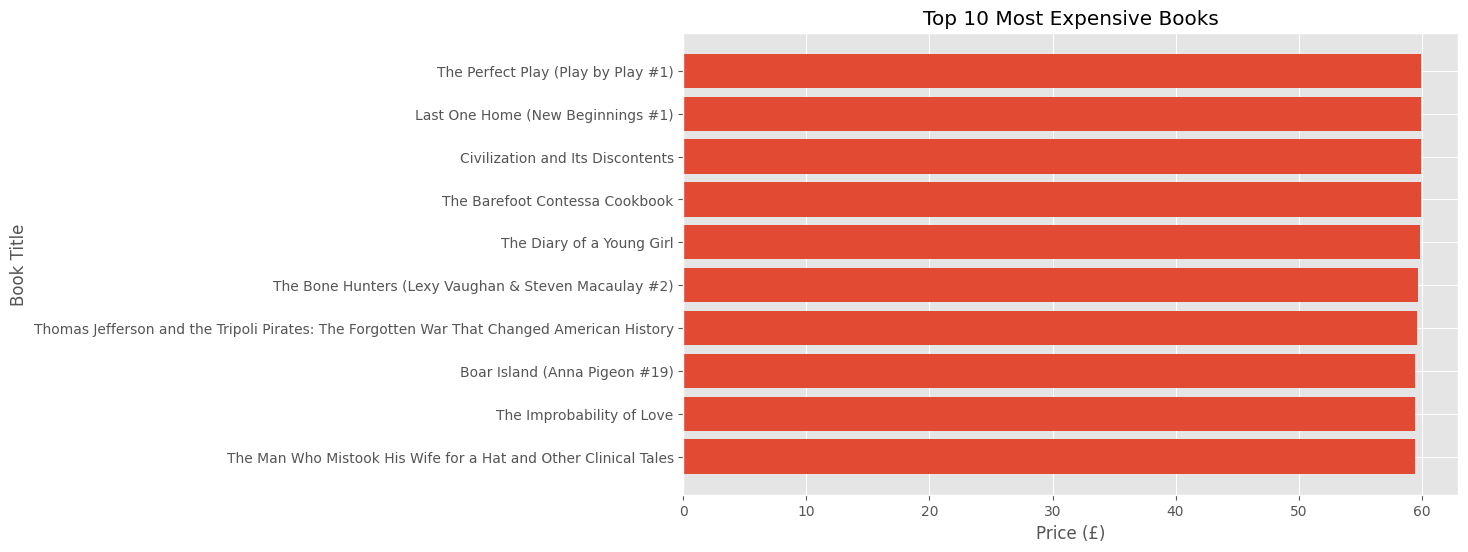

In [7]:
top10 = df.nlargest(10, "Price")

plt.figure(figsize=(10,6))

plt.barh(top10["Title"], top10["Price"])

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")
plt.ylabel("Book Title")

plt.gca().invert_yaxis()

plt.show()

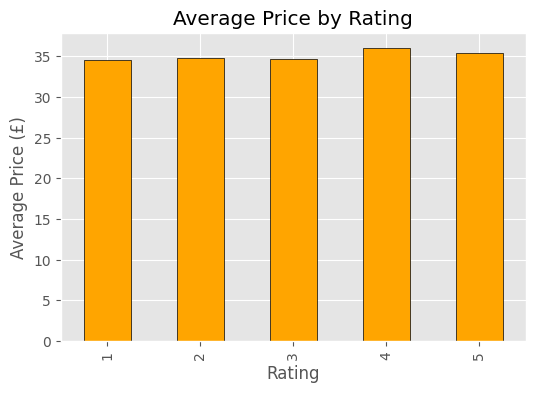

In [8]:
average_price = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(6,4))

average_price.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")

plt.show()

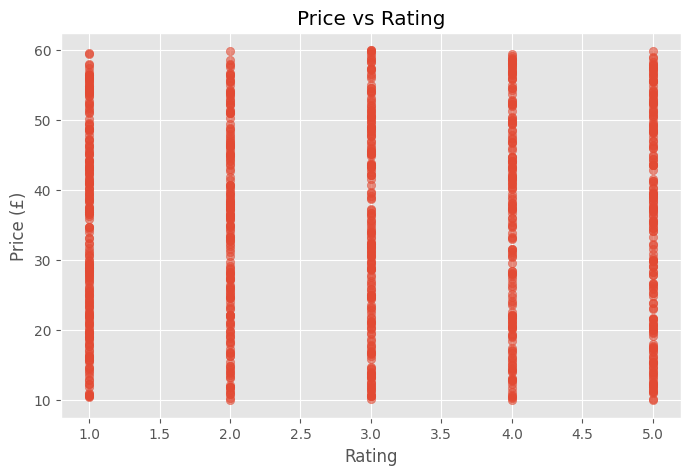

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Rating"],
    df["Price"],
    alpha=0.6
)

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.show()

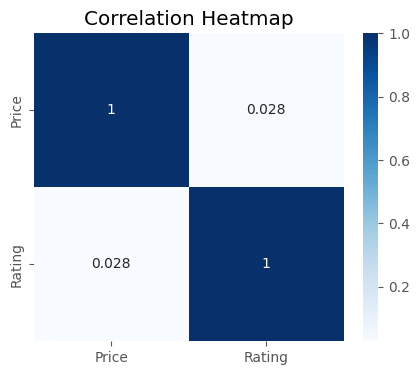

In [10]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df[["Price","Rating"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

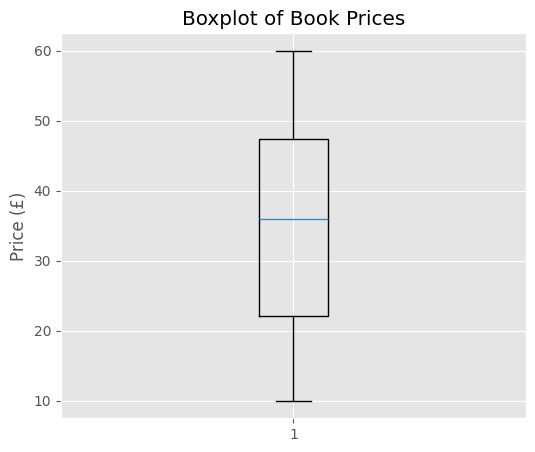

In [11]:
plt.figure(figsize=(6,5))

plt.boxplot(df["Price"])

plt.title("Boxplot of Book Prices")
plt.ylabel("Price (£)")

plt.show()

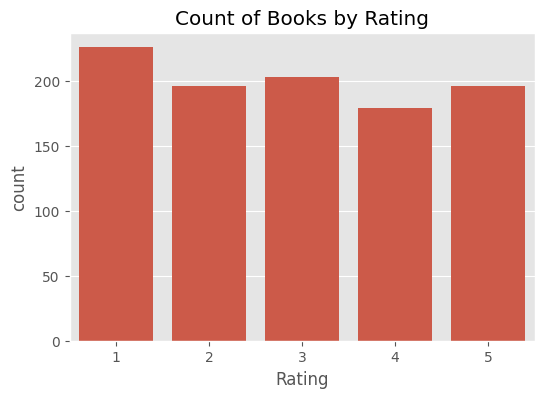

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Rating",
    data=df
)

plt.title("Count of Books by Rating")

plt.show()

In [13]:
print("DATA VISUALIZATION INSIGHTS")
print("-"*40)

print(f"Total Books : {len(df)}")

print(f"Average Price : £{df['Price'].mean():.2f}")

print(f"Highest Price : £{df['Price'].max():.2f}")

print(f"Lowest Price : £{df['Price'].min():.2f}")

print("\nAverage Price by Rating")

print(df.groupby("Rating")["Price"].mean())

DATA VISUALIZATION INSIGHTS
----------------------------------------
Total Books : 1000
Average Price : £35.07
Highest Price : £59.99
Lowest Price : £10.00

Average Price by Rating
Rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: Price, dtype: float64


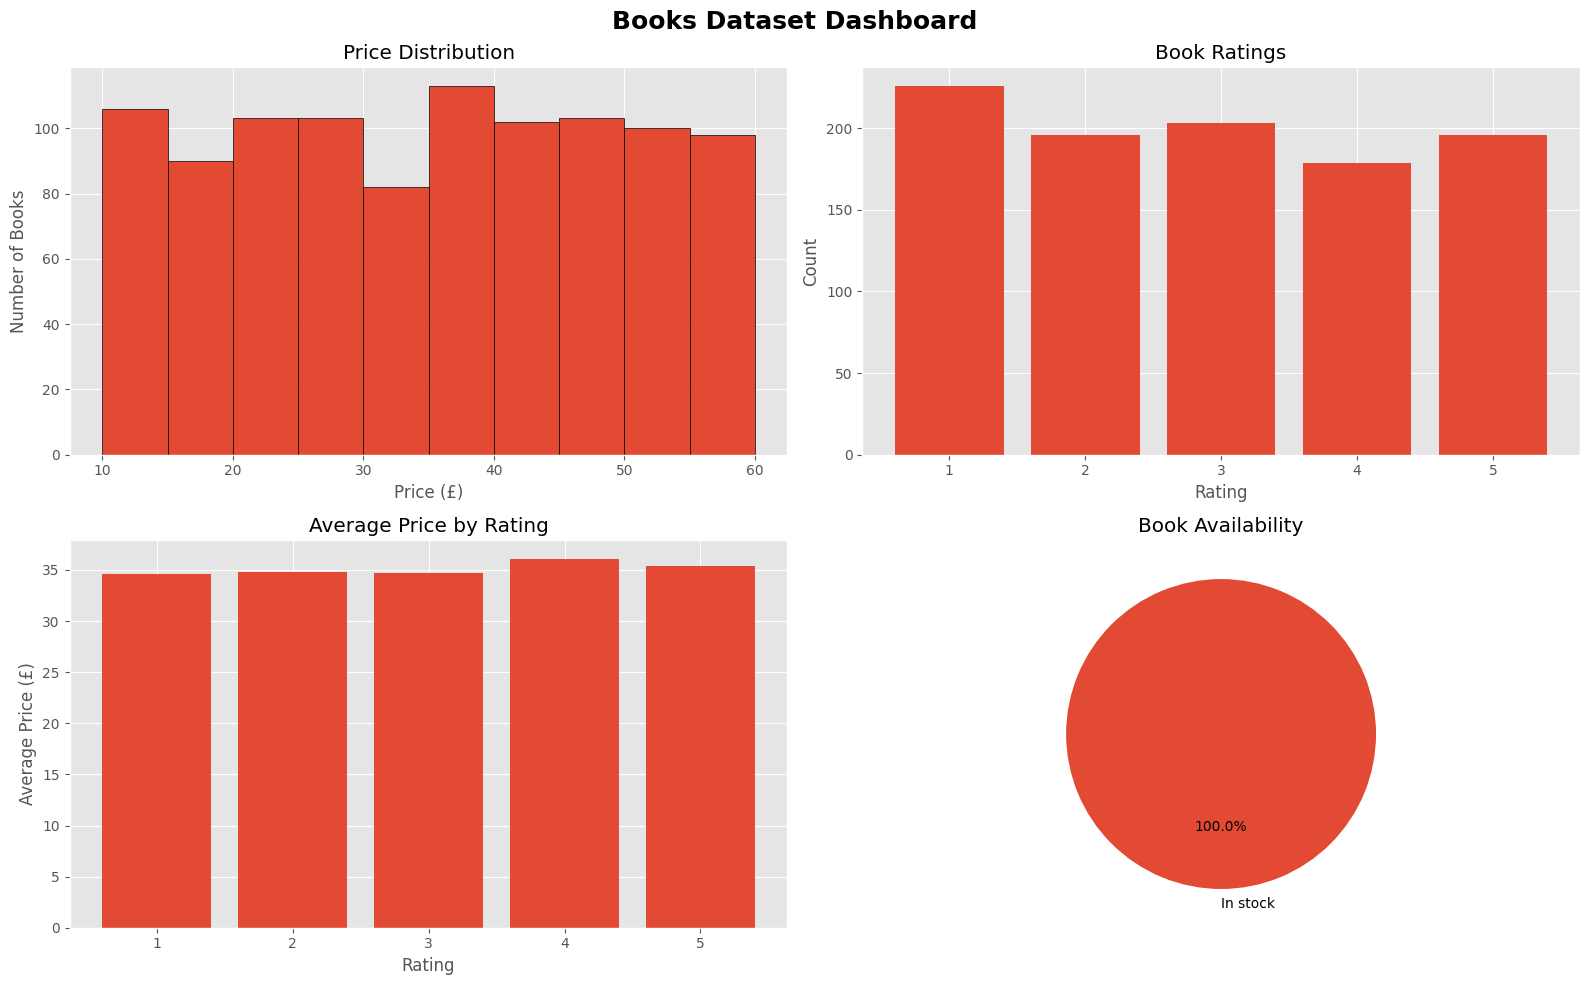

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/cleaned_books.csv")

# Create dashboard
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# -------------------------------
# 1. Price Distribution
# -------------------------------
axs[0, 0].hist(df["Price"], bins=10, edgecolor="black")
axs[0, 0].set_title("Price Distribution")
axs[0, 0].set_xlabel("Price (£)")
axs[0, 0].set_ylabel("Number of Books")

# -------------------------------
# 2. Rating Distribution
# -------------------------------
rating_counts = df["Rating"].value_counts().sort_index()

axs[0, 1].bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

axs[0, 1].set_title("Book Ratings")
axs[0, 1].set_xlabel("Rating")
axs[0, 1].set_ylabel("Count")

# -------------------------------
# 3. Average Price by Rating
# -------------------------------
avg_price = df.groupby("Rating")["Price"].mean()

axs[1, 0].bar(
    avg_price.index.astype(str),
    avg_price.values
)

axs[1, 0].set_title("Average Price by Rating")
axs[1, 0].set_xlabel("Rating")
axs[1, 0].set_ylabel("Average Price (£)")

# -------------------------------
# 4. Availability
# -------------------------------
availability = df["Availability"].value_counts()

axs[1, 1].pie(
    availability,
    labels=availability.index,
    autopct="%1.1f%%",
    startangle=90
)

axs[1, 1].set_title("Book Availability")

# Dashboard Title
plt.suptitle(
    "Books Dataset Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# Save Dashboard
plt.savefig("../screenshots/dashboard.png", dpi=300)

plt.show()